In Class Group Exercise 3 - Gyroscopic Motion

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import DynCon_Functions as df
from scipy.integrate import solve_ivp

Problem 1

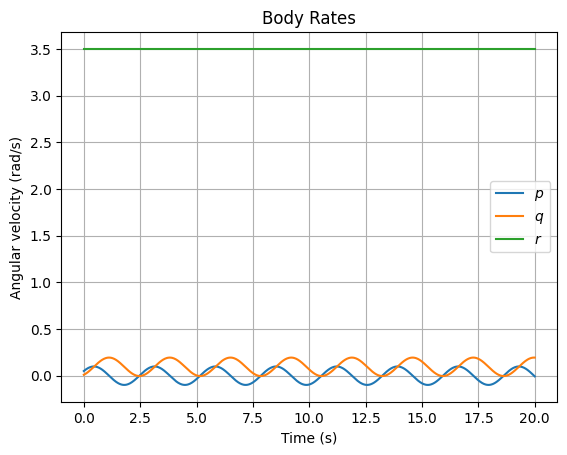

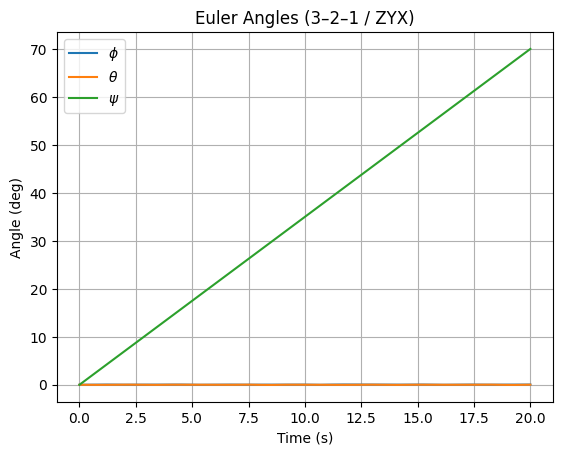

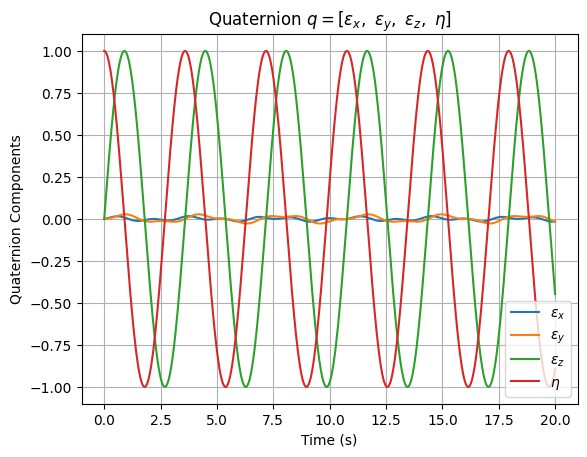

In [2]:
# Initial angular velocity in the body frame
wb0 = np.array([.05, .01, 3.5], dtype=float)
# thrust vector in the body frame
Ftb = np.array([0, 10*np.cos(np.deg2rad(.5)), 10*np.sin(np.deg2rad(.5))], dtype=float)
# Thrust position vector in the body frame
Rtb = np.array([0, 0, 1], dtype=float)
# Torque vector 
Tb = np.cross(Ftb, Rtb)
# Inertia matrix
J = np.array([
    [45, 0, 0],
    [0, 45, 0],
    [0, 0, 75]
])
# Initial euler angles
euler0 = np.zeros(3)
# Initial Quat
q0 = np.array([0, 0, 0, 1], dtype=float)
# State vector
y0 = np.hstack((wb0, euler0, q0))
# Time
t0 = 0
tf = 20
t_eval = np.linspace(t0, tf, 1001)

sol = solve_ivp(lambda t, y:  df.torq_to_eulerquat(t, y, Tb, J),
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval,
    rtol=1e-9, atol=1e-12, method='RK45'
)

t = sol.t
p, q, r = sol.y[0:3, :]
phi, theta, psi = sol.y[3:6, :]
eps1, eps2, eps3, eta = sol.y[6:10, :]

quat = np.array([eps1, eps2, eps3, eta])

for i in range(quat.shape[1]):
    quat[:, i] /= np.linalg.norm(quat[:, i])

eps1, eps2, eps3, eta = quat

plt.figure()
plt.plot(t, p, label=r"$p$")
plt.plot(t, q, label=r"$q$")
plt.plot(t, r, label=r"$r$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angular velocity (rad/s)")
plt.title("Body Rates"); plt.legend()

plt.figure()
plt.plot(t, phi, label=r"$\phi$")
plt.plot(t, theta, label=r"$\theta$")
plt.plot(t, psi, label=r"$\psi$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angle (deg)")
plt.title("Euler Angles (3–2–1 / ZYX)"); plt.legend()

plt.figure()
plt.plot(t, eps1, label=r"$\epsilon_x$")
plt.plot(t, eps2, label=r"$\epsilon_y$")
plt.plot(t, eps3, label=r"$\epsilon_z$")
plt.plot(t, eta, label=r"$\eta$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Quaternion Components")
plt.title(r"Quaternion $q=[\epsilon_x,\ \epsilon_y,\ \epsilon_z,\ \eta]$")
plt.legend()

plt.show()

Problem 3

Problem 4

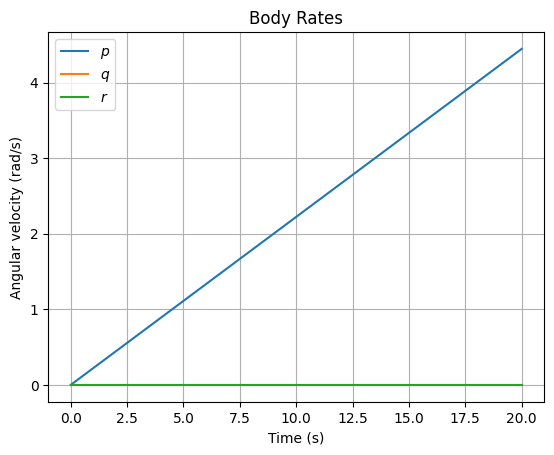

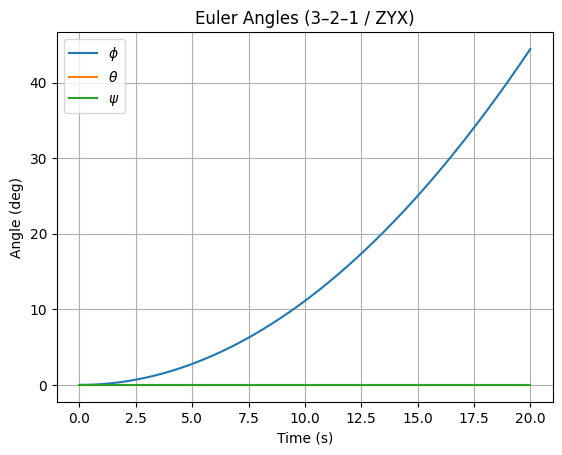

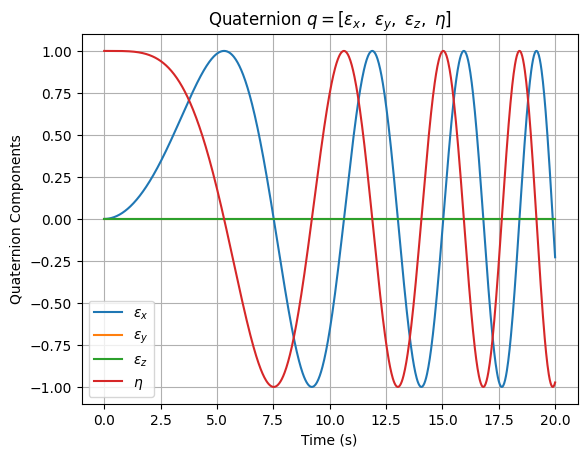

In [3]:
# Initial angular velocity
wb0 = np.zeros(3)
# Initial euler angles
euler0 = np.zeros(3)
# Initial Quat
q0 = np.array([0, 0, 0, 1], dtype=float)
# State vector
y0 = np.hstack((wb0, euler0, q0))
# Time
t0 = 0
tf = 20
t_eval = np.linspace(t0, tf, 1001)

sol = solve_ivp(lambda t, y:  df.torq_to_eulerquat(t, y, Tb, J),
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval,
    rtol=1e-9, atol=1e-12, method='RK45'
)

t = sol.t
p, q, r = sol.y[0:3, :]
phi, theta, psi = sol.y[3:6, :]
eps1, eps2, eps3, eta = sol.y[6:10, :]

quat = np.array([eps1, eps2, eps3, eta])

for i in range(quat.shape[1]):
    quat[:, i] /= np.linalg.norm(quat[:, i])

eps1, eps2, eps3, eta = quat

plt.figure()
plt.plot(t, p, label=r"$p$")
plt.plot(t, q, label=r"$q$")
plt.plot(t, r, label=r"$r$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angular velocity (rad/s)")
plt.title("Body Rates"); plt.legend()

plt.figure()
plt.plot(t, phi, label=r"$\phi$")
plt.plot(t, theta, label=r"$\theta$")
plt.plot(t, psi, label=r"$\psi$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Angle (deg)")
plt.title("Euler Angles (3–2–1 / ZYX)"); plt.legend()

plt.figure()
plt.plot(t, eps1, label=r"$\epsilon_x$")
plt.plot(t, eps2, label=r"$\epsilon_y$")
plt.plot(t, eps3, label=r"$\epsilon_z$")
plt.plot(t, eta, label=r"$\eta$")
plt.grid(True); plt.xlabel("Time (s)"); plt.ylabel("Quaternion Components")
plt.title(r"Quaternion $q=[\epsilon_x,\ \epsilon_y,\ \epsilon_z,\ \eta]$")
plt.legend()

plt.show()